# 4. EDA — Análise Exploratória de Dados

Quarta fase do CRISP-DM. Aqui as sete hipóteses formuladas no notebook 01 são testadas estatisticamente, usando as técnicas vistas no material da Fase 1: testes de hipóteses para diferença de médias, testes de proporções, intervalos de confiança, correlação de Pearson, regressão linear simples e múltipla (incluindo termos de interação) e distribuição binomial.

A organização do notebook segue a agenda de hipóteses:

- **4.1** Carregamento e setup
- **4.2** Panorama univariado das variáveis vs. a target
- **4.3** H1: ponto de ruptura em `delivery_time_days`
- **4.4** H2: interação `delivery_delay_days` × `order_value`
- **4.5** H3: Service Recovery Paradox
- **4.6** H4: blind spots `csat_internal_score` vs. `nps_score`
- **4.7** H5: NPS prediz recompra
- **4.8** H6: detrator silencioso
- **4.9** H7: região explicada por operacional
- **4.10** Síntese: o que cada hipótese mostrou
- **4.11** Insights de negócio consolidados
- **4.12** Conclusão da fase

Cada seção de hipótese segue o mesmo padrão: pergunta de pesquisa, método estatístico aplicado, resultado quantitativo, interpretação de negócio. As decisões metodológicas vão sempre justificar a escolha técnica em função do que o negócio precisa entender.

## 4.1 Carregamento e setup

Diferente dos notebooks anteriores que carregavam o CSV bruto, esta fase parte do **dataset processado** salvo em `data/processed/dados_processados.csv`. As transformações aplicadas no notebook 03 (categorização do NPS, conversões para `Categorical`, variáveis log derivadas, renomeação) já estão presentes, e a função do módulo `src/nps/data.py` reconstrói os tipos categóricos automaticamente na leitura.

O setup visual segue o padrão dos notebooks anteriores: tema seaborn whitegrid, paleta de cores semânticas para os buckets de NPS (vermelho para detrator, cinza para neutro, verde para promotor) reaproveitada em toda a EDA.

In [1]:
# Bibliotecas principais
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Funcoes do nosso modulo
from nps.data import carregar_dataset_processado
from nps.features import CATEGORIAS_NPS_ORDEM

# Reprodutibilidade
SEMENTE_ALEATORIA = 42
np.random.seed(SEMENTE_ALEATORIA)

# Configuracao visual padrao
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100

# Cores semanticas que serao usadas em todas as visualizacoes da EDA
CORES_BUCKETS = {
    "detrator": "#e74c3c",
    "neutro":   "#95a5a6",
    "promotor": "#27ae60",
}
ORDEM_BUCKETS = list(CATEGORIAS_NPS_ORDEM)

# Caminhos para esse notebook
RAIZ_PROJETO = Path.cwd().parent
PASTA_FIGURAS = RAIZ_PROJETO / "reports" / "figures" / "04_eda"
PASTA_FIGURAS.mkdir(parents=True, exist_ok=True)

# Carrega o dataset processado (com tipos categoricos reconstituidos)
dados = carregar_dataset_processado()

print(f"Dataset processado carregado: {dados.shape[0]:,} linhas x {dados.shape[1]} colunas")
print(f"Tipos das colunas categoricas reconstituidas:")
print(f"  categoria_nps:    {dados['categoria_nps'].dtype}, ordenada={dados['categoria_nps'].cat.ordered}")
print(f"  customer_region:  {dados['customer_region'].dtype}, ordenada={dados['customer_region'].cat.ordered}")

Dataset processado carregado: 2,500 linhas x 23 colunas
Tipos das colunas categoricas reconstituidas:
  categoria_nps:    category, ordenada=True
  customer_region:  category, ordenada=False


Tudo carregado conforme esperado: 2.500 linhas, 23 colunas, com `categoria_nps` ordenada (detrator < neutro < promotor) e `customer_region` não-ordenada. As variáveis derivadas no notebook 03 (`log_order_value`, `log_discount_value`, `houve_recompra_30d`) também estão disponíveis. A próxima seção começa com um panorama univariado das variáveis em relação à target, antes de mergulhar nas hipóteses específicas.

## 4.2 Panorama univariado: correlação com a target

Antes de testar as hipóteses específicas, vale ter uma visão geral de como cada variável numérica se relaciona com o `nps_score`. A ferramenta para isso é a **correlação de Pearson**, que mede o grau de associação linear entre duas variáveis numéricas e produz um valor entre -1 e +1: valores próximos de +1 indicam que as duas variáveis sobem juntas, próximos de -1 que uma sobe quando a outra desce, e próximos de 0 que não há associação linear clara.

Vou olhar primeiro o panorama completo (todas contra todas) e depois um recorte focado em quem mais correlaciona com a target. Esse é um passo de **descoberta exploratória**, não conclusão: correlações altas vão virar pontos de partida para os testes formais nas próximas seções, e correlações próximas de zero vão receber atenção especial nas hipóteses sobre relações não-lineares.

### Por que Pearson, e não outra medida

Pearson é o coeficiente padrão para variáveis numéricas em escala razoavelmente normal e foi visto no material da fase 1. Tem uma limitação importante: ele só capta **relação linear**. Se uma variável afeta o NPS de forma não-linear (por exemplo, "abaixo de 5 dias o efeito é zero, acima de 8 a queda é forte"), o coeficiente de Pearson pode estar próximo de zero mesmo que a relação real seja forte. Isso vai ser importante para a interpretação da hipótese H1 mais adiante.

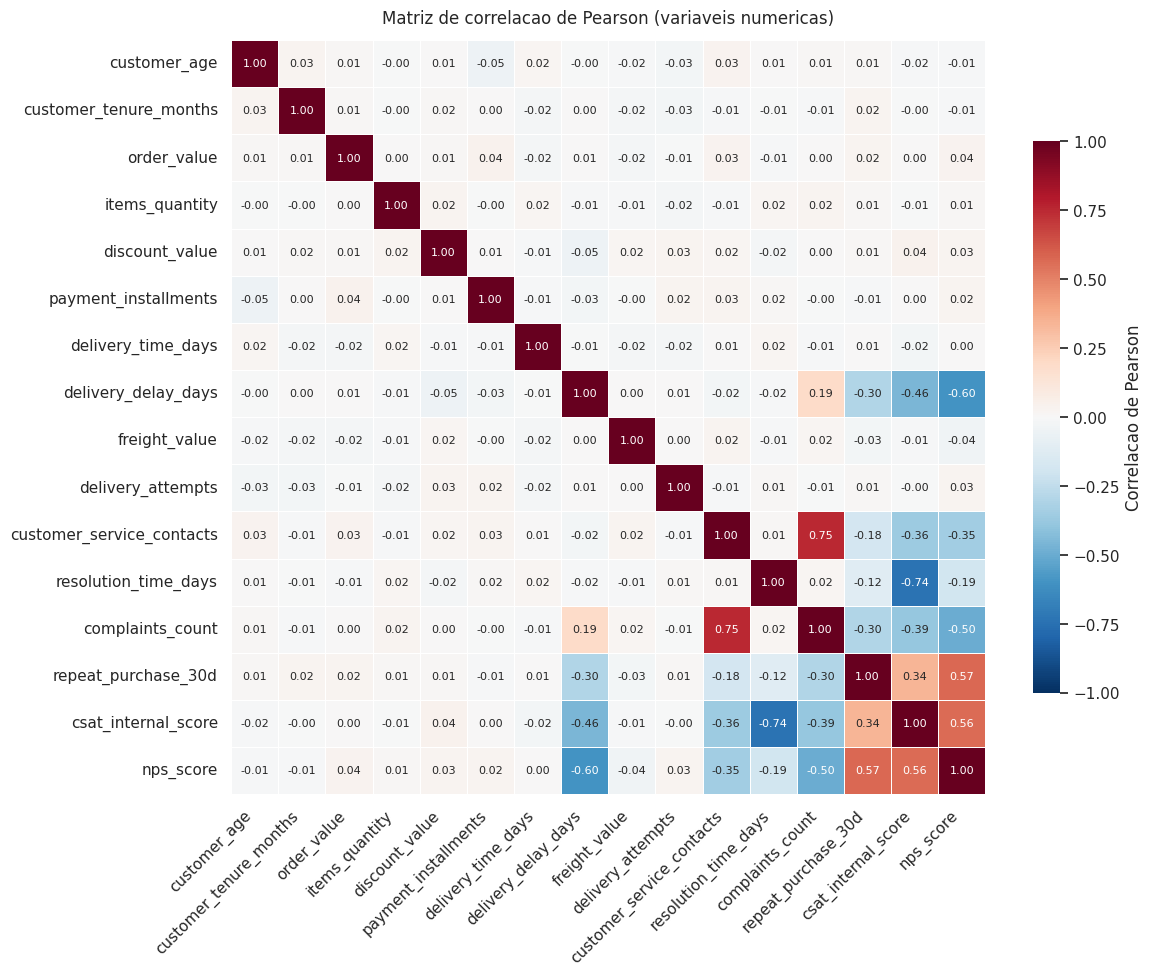

In [2]:
# Variaveis numericas relevantes (excluindo IDs e a copia houve_recompra_30d)
variaveis_numericas = [
    "customer_age", "customer_tenure_months",
    "order_value", "items_quantity", "discount_value", "payment_installments",
    "delivery_time_days", "delivery_delay_days", "freight_value", "delivery_attempts",
    "customer_service_contacts", "resolution_time_days", "complaints_count",
    "repeat_purchase_30d",
    "csat_internal_score",
    "nps_score",
]

# Matriz de correlacao de Pearson
matriz_corr = dados[variaveis_numericas].corr(method="pearson")

# Heatmap divergente em torno de zero
fig, eixo = plt.subplots(figsize=(12, 10))
sns.heatmap(
    matriz_corr,
    cmap="RdBu_r",
    center=0,
    vmin=-1, vmax=1,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8},
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.7, "label": "Correlacao de Pearson"},
    ax=eixo,
)
eixo.set_title("Matriz de correlacao de Pearson (variaveis numericas)", fontsize=12, pad=12)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
fig.tight_layout()
fig.savefig(PASTA_FIGURAS / "4_2_heatmap_correlacao.png", dpi=120, bbox_inches="tight")
plt.show()

![Matriz de correlação de Pearson das variáveis numéricas](../reports/figures/04_eda/4_2_heatmap_correlacao.png)

**Como ler este gráfico:** uma **matriz quadrada** onde cada linha e cada coluna representa uma variável numérica. Cada célula mostra o **coeficiente de correlação de Pearson** entre as duas variáveis cruzadas, com o valor numérico anotado dentro. A escala de cores vai de **azul forte (correlação negativa, próxima de -1)** a **vermelho forte (correlação positiva, próxima de +1)**, passando pelo branco em zero (sem correlação linear). A **diagonal principal sempre é vermelho intenso (1,00)** porque é a correlação de cada variável com ela mesma. Para entender o impacto de cada variável na target, basta olhar a **linha ou coluna do `nps_score`** e identificar as cores mais fortes.

Algumas leituras importantes do heatmap.

**Coluna do `nps_score` (que é o que mais nos interessa nesta fase):** as cores mais fortes aparecem em poucas variáveis, e em duas direções diferentes.

Em **azul (correlação negativa)**, três variáveis se destacam: `delivery_delay_days`, `complaints_count` e `customer_service_contacts`. Faz sentido econômico: cliente com mais atraso, mais reclamações ou mais contatos no SAC tende a dar nota menor de NPS. A magnitude de `delivery_delay_days` (em torno de -0,60) é a maior associação linear negativa do dataset com a target.

Em **vermelho (correlação positiva)**, duas variáveis aparecem com força semelhante: `csat_internal_score` (aproximadamente +0,56) e `repeat_purchase_30d` (+0,57). A correlação alta com CSAT confirma a preocupação que tínhamos sobre target leakage (CSAT carrega informação parecida com a do NPS). A correlação alta com recompra é boa notícia para a hipótese H5: já antecipa que NPS deve mesmo prever recompra.

**Variáveis com correlação próxima de zero** com o NPS: idade, tenure, valor do pedido, quantidade de itens, parcelas, frete e tentativas de entrega têm coeficientes praticamente nulos. Isso era esperado para algumas dessas (idade, tenure parecem ter sido sorteadas independentemente da target no dataset sintético), mas há um caso suspeito: `delivery_time_days`. Logicamente, era para ter alguma relação, mas o coeficiente Pearson dela com NPS é praticamente zero.

**Atenção a esse achado:** Pearson capta só relação linear. Se o efeito do tempo de entrega for tipo "abaixo de 5 dias o NPS não muda muito; acima de 8 dias o NPS desaba", isso pode produzir correlação Pearson próxima de zero mesmo com relação real forte. Esse é exatamente o cenário descrito pela hipótese H1, e justifica investigar a variável com técnica diferente (segmentação por faixas) na seção 4.3.

**Outras observações úteis** que vão importar para a modelagem mais adiante: variáveis de atendimento têm correlações moderadas entre si (`complaints_count` × `customer_service_contacts`, `customer_service_contacts` × `resolution_time_days`), o que é colinearidade esperada. `freight_value` correlaciona positivamente com `order_value` (frete tende a subir com pedido maior). Nada disso surpreende, mas é bom ter mapeado.

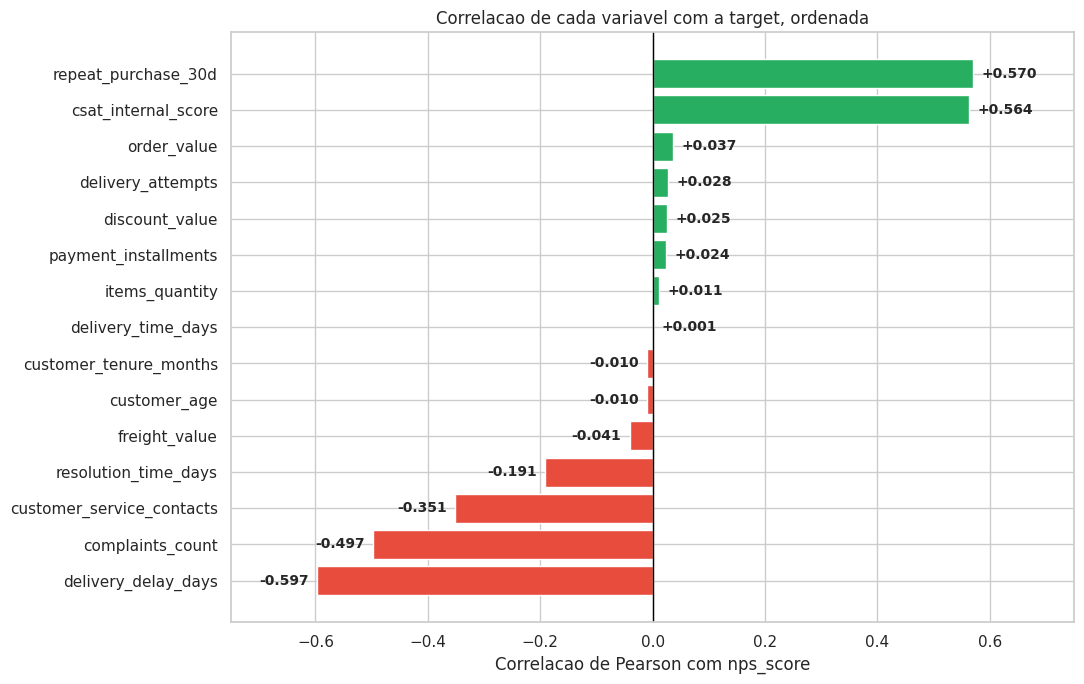

In [3]:
# Bar chart focado na correlacao de cada variavel com a target
correlacoes_com_nps = matriz_corr["nps_score"].drop("nps_score").sort_values()

# Cores: vermelho para correlacao negativa, verde para positiva
cores_barras = ["#e74c3c" if v < 0 else "#27ae60" for v in correlacoes_com_nps.values]

fig, eixo = plt.subplots(figsize=(11, 7))
barras = eixo.barh(correlacoes_com_nps.index, correlacoes_com_nps.values, color=cores_barras, edgecolor="white")

# Anota o valor numerico em cada barra
for i, v in enumerate(correlacoes_com_nps.values):
    deslocamento = 0.015 if v >= 0 else -0.015
    alinhamento = "left" if v >= 0 else "right"
    eixo.text(v + deslocamento, i, f"{v:+.3f}", va="center", ha=alinhamento, fontsize=10, fontweight="bold")

eixo.axvline(0, color="black", linewidth=1)
eixo.set_xlim(-0.75, 0.75)
eixo.set_xlabel("Correlacao de Pearson com nps_score")
eixo.set_title("Correlacao de cada variavel com a target, ordenada")
fig.tight_layout()
fig.savefig(PASTA_FIGURAS / "4_2_correlacao_com_nps.png", dpi=120, bbox_inches="tight")
plt.show()

![Correlação de cada variável com a target ordenada](../reports/figures/04_eda/4_2_correlacao_com_nps.png)

**Como ler este gráfico:** o eixo X mostra o **coeficiente de correlação de Pearson** com `nps_score`, indo de -0,75 a +0,75. Cada barra horizontal é uma variável do dataset, ordenada da mais negativa (no topo) para a mais positiva (em baixo). **Barras vermelhas** indicam correlação negativa (a variável tende a baixar o NPS); **verdes** indicam correlação positiva (tendem a subir). O comprimento de cada barra é proporcional à força da relação. A linha vertical preta em zero é a referência para distinguir os dois lados, e barras muito curtas (próximas dela) significam variáveis sem relação linear detectável com a target.

O bar chart deixa o ranking explícito. Em valor absoluto, a hierarquia das correlações lineares com NPS é:

1. `delivery_delay_days` (-0,60)
2. `repeat_purchase_30d` (+0,57)
3. `csat_internal_score` (+0,56)
4. `complaints_count` (-0,50)
5. `customer_service_contacts` (-0,35)
6. `resolution_time_days` (-0,19)

E uma cauda longa de variáveis com correlação praticamente nula (`freight_value`, `customer_age`, `customer_tenure_months`, `delivery_time_days`, `items_quantity`, `payment_installments`, `discount_value`, `delivery_attempts`).

Esse panorama dá três pistas importantes para a sequência da EDA.

A **logística está claramente associada à target**, principalmente via atraso (`delivery_delay_days`), o que era a expectativa. A interação dessa variável com `order_value`, prevista pela hipótese H2, vai ser testada formalmente na seção 4.4.

O **atendimento entra como segundo bloco mais relevante**, mas com a ressalva já discutida no notebook 01: contatos com SAC e reclamações são possivelmente sintoma do problema, não causa. As hipóteses H3 (Service Recovery Paradox) e H6 (detrator silencioso) vão tentar separar esses efeitos.

E o **mistério do `delivery_time_days` quase nulo** vai ser o foco da hipótese H1: existe um ponto de ruptura, ou a variável de tempo total realmente não importa? Como Pearson é cego para não-linearidade, vamos precisar de outra abordagem para responder.

Com esse panorama em mente, as próximas seções vão testar cada uma das sete hipóteses formuladas no notebook 01.